# Perception Stack - Notebook 02b: Depth Estimation via Depth Anything V2

This notebook runs Stage 3 of the Perception Stack pipeline.
Depth Anything V2 Small is applied to physically significant frames for each clip:
the overlap frames detected by SAM 2 and the final frame (frame 127).
Per-object depth scalars are extracted at SAM 2 centroid positions and used to
classify whether overlapping object pairs share the same collision plane.
An empirical depth threshold is derived from ground truth annotation collision events.

## Steps
- Mount Google Drive and define all constants and paths
- Install dependencies and load SAM 2 NPZ outputs and annotation files
- Load confirmed collision events from annotation JSONs and compute t-5 frames
  for threshold derivation
- Load Depth Anything V2 Small via the HuggingFace pipeline API
- Run depth sanity check: visualize RGB and normalized depth maps for 2 clips
- Derive the collision-plane depth threshold empirically from ground truth
  annotation collisions at t-5 frames; save threshold to Drive
- Run main inference loop across all 70 clips with per-clip checkpointing:
  for each overlap pair, run DAv2 at the overlap frame; for all visible objects,
  run DAv2 at the final frame; extract depth scalars at centroid positions
- Save per-clip depth results as compressed `.npz` to Drive
- Verify saved NPZ outputs
- Generate depth map visualizations and context string previews for 2 clips
- Report final Drive storage usage

---
> **Note:** This notebook is natively developed and run on Google Colab (T4 GPU sufficient).
> If it does not render correctly in your viewer, please open it directly on Colab:
> [Open in Google Colab](<https://colab.research.google.com/drive/1UBdL1nI94lAm2DP8dePO3m3v_bYpzqfI?usp=sharing>)

---
# Cell 1 — Mount Drive + Constants + Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── CLEAR: Delete all NB02b outputs ────────────────────────────────────────
import os

BASE = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"

# Clear depth npz files
depth_dir = os.path.join(BASE, "outputs/stage2_depth")
deleted = 0
for f in os.listdir(depth_dir):
    if f.startswith("stage2_depth_") and f.endswith(".npz"):
        os.remove(os.path.join(depth_dir, f))
        deleted += 1
print(f"Deleted {deleted} depth npz files")

# Clear depth threshold
thresh_path = os.path.join(BASE, "outputs/depth_threshold.json")
if os.path.exists(thresh_path):
    os.remove(thresh_path)
    print("Deleted depth_threshold.json")

# Clear NB02b figures
fig_dir = os.path.join(BASE, "figures")
deleted_figs = 0
for f in os.listdir(fig_dir):
    if f.startswith("02b_"):
        os.remove(os.path.join(fig_dir, f))
        deleted_figs += 1
print(f"Deleted {deleted_figs} NB02b figures")

print("NB02b slate cleared.")

Deleted 2 depth npz files
Deleted depth_threshold.json
Deleted 3 NB02b figures
NB02b slate cleared.


In [4]:
import os
import json

# ── Constants ──────────────────────────────────────────────────────────────
NO_CLIPS   = 70      # change this one number to scale up
SEED       = 42
MODEL_ID   = "depth-anything/Depth-Anything-V2-Small-hf"

# ── Base path on Drive ─────────────────────────────────────────────────────
BASE          = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"
CLIPS_DIR     = os.path.join(BASE, "data/clips")
ANN_DIR       = os.path.join(BASE, "data/annotations")
ID_PATH       = os.path.join(BASE, "data/selected_clip_ids.json")
SAM2_DIR      = os.path.join(BASE, "outputs/stage1_sam2")
OUT_DEPTH     = os.path.join(BASE, "outputs/stage2_depth")
FIGURES_DIR   = os.path.join(BASE, "figures")

os.makedirs(OUT_DEPTH, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Load selected clip IDs ─────────────────────────────────────────────────
with open(ID_PATH, 'r') as f:
    ALL_SELECTED_IDS = json.load(f)

SELECTED_IDS = ALL_SELECTED_IDS[:NO_CLIPS]
print(f"Drive mounted.")
print(f"Working with {NO_CLIPS} clips: {SELECTED_IDS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Working with 70 clips: [10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009, 10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018, 10019, 10020, 10021, 10022, 10023, 10024, 10025, 10026, 10027, 10028, 10029, 10030, 10031, 10032, 10033, 10034, 10035, 10036, 10037, 10038, 10039, 10040, 10041, 10042, 10043, 10044, 10045, 10046, 10047, 10048, 10049, 10050, 10051, 10052, 10053, 10054, 10055, 10056, 10057, 10058, 10059, 10060, 10061, 10062, 10063, 10064, 10065, 10066, 10067, 10068, 10069, 10070]


---
# Cell 2 -Install Dependencies

In [5]:
# ── Cell 2 — Install Dependencies ──────────────────────────────────────────
!pip install -q transformers accelerate pillow opencv-python-headless

print("Dependencies installed.")

Dependencies installed.


---
# Cell 3 - Load SAM 2 Outputs + Extract Depth Sampling Targets

In [6]:
# ── Cell 3 — Load SAM 2 Outputs + Extract Depth Sampling Targets ───────────
import numpy as np

def load_sam2_outputs(vid_id):
    """
    Load SAM 2 NPZ for a clip and extract:
    - overlap pairs with their frames
    - all visible object centroids at last frame (127)
    """
    npz_path = os.path.join(SAM2_DIR, f"stage1_sam2_{vid_id:05d}.npz")
    data     = np.load(npz_path, allow_pickle=True)

    # ── Object labels ───────────────────────────────────────────────────────
    obj_labels = list(data['obj_labels'])

    # ── Overlap pairs ───────────────────────────────────────────────────────
    overlap_obj_a  = list(data['overlap_obj_a'])
    overlap_obj_b  = list(data['overlap_obj_b'])
    overlap_frames = list(data['overlap_frames'])

    overlaps = []
    for obj_a, obj_b, frame in zip(overlap_obj_a, overlap_obj_b, overlap_frames):
        overlaps.append({
            'obj_a' : obj_a,
            'obj_b' : obj_b,
            'frame' : int(frame)
        })

    # ── Last frame centroids (frame 127) ────────────────────────────────────
    last_frame_centroids = {}
    for label in obj_labels:
        centroids = data[f"{label}__centroids"]   # (128, 2)
        cx, cy    = centroids[127]
        if not (np.isnan(cx) or np.isnan(cy)):
            last_frame_centroids[label] = (float(cx), float(cy))

    return {
        'obj_labels'          : obj_labels,
        'overlaps'            : overlaps,
        'last_frame_centroids': last_frame_centroids
    }

In [7]:
# ── Verify for selected clips ──────────────────────────────────────────
for vid_id in SELECTED_IDS[:2]:
    result = load_sam2_outputs(vid_id)

    print(f"\nClip {vid_id}:")
    print(f"  Objects       : {result['obj_labels']}")
    print(f"  Overlap pairs : {len(result['overlaps'])}")
    for ov in result['overlaps']:
        print(f"    {ov['obj_a']} <-> {ov['obj_b']} at frame {ov['frame']}")
    print(f"  Last frame visible objects: {len(result['last_frame_centroids'])}")
    for label, (cx, cy) in result['last_frame_centroids'].items():
        print(f"    {label}: centroid ({cx:.1f}, {cy:.1f})")

print("\nCell 3 complete.")


Clip 10001:
  Objects       : [np.str_('brown_metal_cube'), np.str_('gray_metal_cube'), np.str_('green_metal_sphere'), np.str_('yellow_rubber_sphere'), np.str_('yellow_metal_cylinder')]
  Overlap pairs : 2
    gray_metal_cube <-> green_metal_sphere at frame 99
    green_metal_sphere <-> yellow_metal_cylinder at frame 92
  Last frame visible objects: 5
    brown_metal_cube: centroid (338.6, 143.9)
    gray_metal_cube: centroid (403.2, 65.1)
    green_metal_sphere: centroid (462.7, 68.2)
    yellow_rubber_sphere: centroid (347.4, 81.0)
    yellow_metal_cylinder: centroid (439.1, 86.6)

Clip 10002:
  Objects       : [np.str_('blue_metal_cylinder'), np.str_('brown_metal_cylinder'), np.str_('cyan_rubber_cube'), np.str_('gray_metal_sphere'), np.str_('green_metal_cube'), np.str_('gray_rubber_sphere')]
  Overlap pairs : 5
    blue_metal_cylinder <-> green_metal_cube at frame 59
    cyan_rubber_cube <-> green_metal_cube at frame 54
    gray_metal_sphere <-> green_metal_cube at frame 51
    gra

In [8]:
# ── Cell 3b — Annotation Utility Functions ─────────────────────────────────
import json

def load_annotation(vid_id):
    """Load annotation JSON for a given clip ID."""
    ann_path = os.path.join(ANN_DIR, f"annotation_{vid_id}.json")
    with open(ann_path, 'r') as f:
        return json.load(f)

def get_object_properties(annotation):
    """
    Returns dict: {object_id -> {color, material, shape}}
    """
    return {
        obj['object_id']: {
            'color'   : obj['color'],
            'material': obj['material'],
            'shape'   : obj['shape']
        }
        for obj in annotation['object_property']
    }

# ── Verify ──────────────────────────────────────────────────────────────────
for vid_id in SELECTED_IDS[:2]:
    ann       = load_annotation(vid_id)
    obj_props = get_object_properties(ann)
    print(f"Clip {vid_id}: {len(obj_props)} objects loaded from annotation.")

print("\nCell 3b complete.")

Clip 10001: 5 objects loaded from annotation.
Clip 10002: 6 objects loaded from annotation.

Cell 3b complete.


In [9]:
# ── Cell 3b — Load Collision Events from Annotations ───────────────────────

def load_collision_events(vid_ids):
    """
    Load ground truth collision events from annotation files for given clip IDs.
    Returns list of dicts with clip_id, object labels, collision_frame, t_minus_5_frame.
    """
    all_collisions = []

    for vid_id in vid_ids:
        ann       = load_annotation(vid_id)
        obj_props = get_object_properties(ann)

        for collision in ann['collision']:
            obj_id_a   = collision['object_ids'][0]
            obj_id_b   = collision['object_ids'][1]
            col_frame  = collision['frame_id']
            t5_frame   = max(0, col_frame - 5)

            # ── Build labels matching SAM 2 NPZ key format ──────────────────
            props_a  = obj_props[obj_id_a]
            props_b  = obj_props[obj_id_b]
            label_a  = f"{props_a['color']}_{props_a['material']}_{props_a['shape']}"
            label_b  = f"{props_b['color']}_{props_b['material']}_{props_b['shape']}"

            all_collisions.append({
                'vid_id'         : vid_id,
                'label_a'        : label_a,
                'label_b'        : label_b,
                'collision_frame': col_frame,
                't5_frame'       : t5_frame
            })

    return all_collisions

In [10]:
# ── Verify ──────────────────────────────────────────────────────────────────
collisions = load_collision_events(SELECTED_IDS[:2])
print(f"Total collisions found across {len(SELECTED_IDS)} clips: {len(collisions)}\n")
for c in collisions:
    print(f"  Clip {c['vid_id']}: {c['label_a']} <-> {c['label_b']} "
          f"| collision frame {c['collision_frame']} | t-5 frame {c['t5_frame']}")

print("\nCell 3b complete.")

Total collisions found across 70 clips: 7

  Clip 10001: yellow_rubber_sphere <-> green_metal_sphere | collision frame 34 | t-5 frame 29
  Clip 10001: green_metal_sphere <-> yellow_metal_cylinder | collision frame 58 | t-5 frame 53
  Clip 10001: green_metal_sphere <-> gray_metal_cube | collision frame 76 | t-5 frame 71
  Clip 10002: green_metal_cube <-> gray_metal_sphere | collision frame 49 | t-5 frame 44
  Clip 10002: green_metal_cube <-> blue_metal_cylinder | collision frame 69 | t-5 frame 64
  Clip 10002: gray_metal_sphere <-> gray_rubber_sphere | collision frame 108 | t-5 frame 103
  Clip 10002: green_metal_cube <-> gray_rubber_sphere | collision frame 117 | t-5 frame 112

Cell 3b complete.


---

# Cell 4 - loading the DAv2-Small model:

In [11]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [12]:
# ── Cell 4 — Load Depth Anything V2 Small ──────────────────────────────────
import torch
from transformers import pipeline

print("Loading Depth Anything V2 Small...")

depth_pipe = pipeline(
    task            = "depth-estimation",
    model           = MODEL_ID,
    device          = 0 if torch.cuda.is_available() else -1
)

device_name = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Model loaded on : {device_name}")
print(f"VRAM used       : {torch.cuda.memory_allocated() / 1e9:.2f} GB"
      if torch.cuda.is_available() else "Running on CPU")
print("Cell 4 complete.")

Loading Depth Anything V2 Small...


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded on : cuda:0
VRAM used       : 0.10 GB
Cell 4 complete.


---

# Cell 5 — Depth Extraction Function

In [13]:
# ── Cell 5 — Depth Extraction Function ─────────────────────────────────────
import cv2
import numpy as np
from PIL import Image

def extract_frame(vid_id, frame_idx):
    """
    Extract a single frame from a clip .mp4 file.
    Returns PIL Image (RGB).
    """
    clip_path = os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")
    cap       = cv2.VideoCapture(clip_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame {frame_idx} from clip {vid_id}")
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

def get_depth_at_centroid(vid_id, frame_idx, cx, cy):
    """
    Run DAv2 on a single frame and return the depth value at (cx, cy).
    Depth map is normalized to [0, 1] within the frame.
    Returns float depth scalar.
    """
    pil_image  = extract_frame(vid_id, frame_idx)
    result     = depth_pipe(pil_image)
    depth_map  = np.array(result['depth'])

    # ── Normalize depth map to [0, 1] within this frame ────────────────────
    d_min, d_max = depth_map.min(), depth_map.max()
    if d_max > d_min:
        depth_norm = (depth_map - d_min) / (d_max - d_min)
    else:
        depth_norm = np.zeros_like(depth_map, dtype=float)

    # ── Sample at centroid pixel ────────────────────────────────────────────
    px = int(round(cx))
    py = int(round(cy))
    px = np.clip(px, 0, depth_norm.shape[1] - 1)
    py = np.clip(py, 0, depth_norm.shape[0] - 1)

    return round(float(depth_norm[py, px]), 4)

In [14]:
# ── Sanity check on one frame ───────────────────────────────────────────────
print("Sanity check: running DAv2 on frame 127 of clip 10205...")
test_depth = get_depth_at_centroid(10005, 127, 249.5, 36.9)
print(f"  Red rubber sphere depth at last frame: {test_depth}")
print("Cell 5 complete.")

Sanity check: running DAv2 on frame 127 of clip 10205...
  Red rubber sphere depth at last frame: 0.102
Cell 5 complete.


In [16]:
import matplotlib.pyplot as plt

In [18]:
def get_depth_map_normalized(vid_id, frame_idx):
    """
    Run DAv2 on a single frame, return both the normalized depth map
    and the PIL image for visualization.
    """
    pil_image  = extract_frame(vid_id, frame_idx)
    result     = depth_pipe(pil_image)
    depth_map  = np.array(result['depth'])

    d_min, d_max = depth_map.min(), depth_map.max()
    if d_max > d_min:
        depth_norm = (depth_map - d_min) / (d_max - d_min)
    else:
        depth_norm = np.zeros_like(depth_map, dtype=float)

    return pil_image, depth_norm

Clip 10001 -- depth range: 0.000 to 1.000
Clip 10002 -- depth range: 0.000 to 1.000


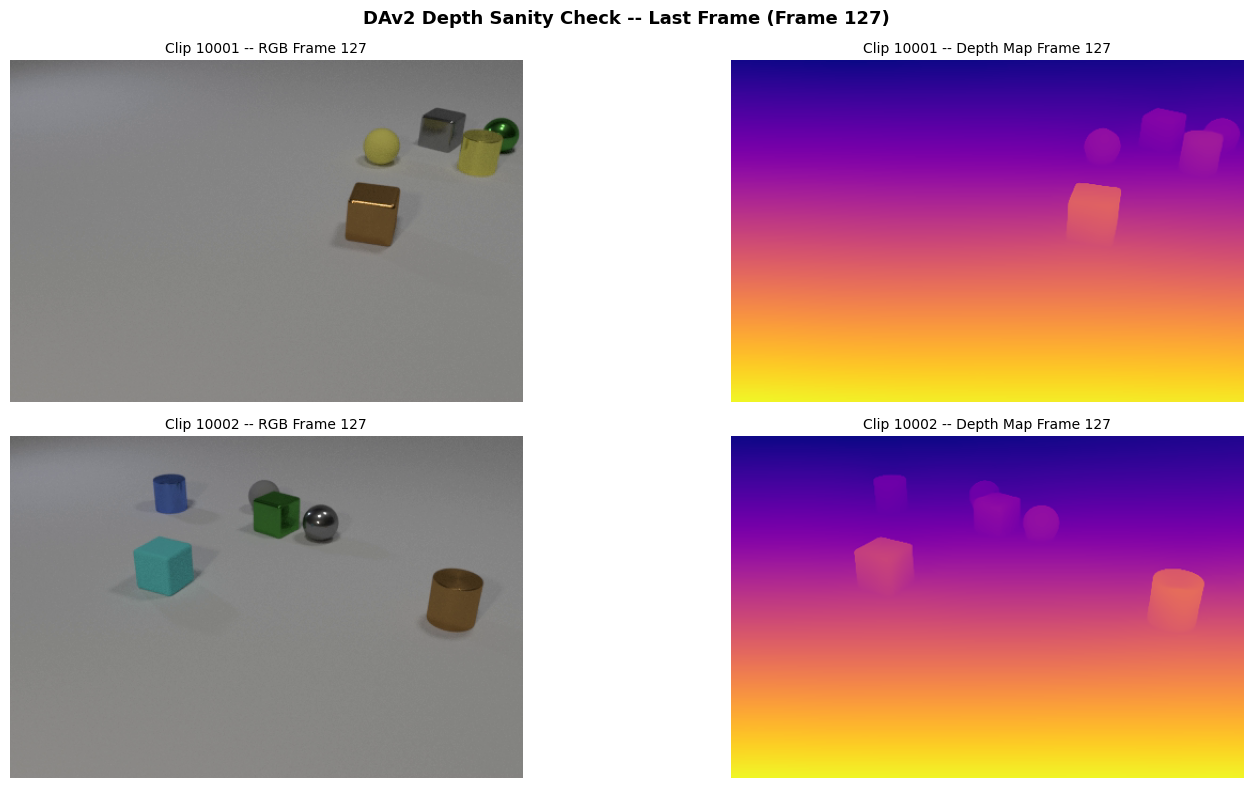

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02b_sanity_check.jpg
Cell 5b complete.


In [19]:
# ── Cell 5b — Sanity Check: Depth visualization for first 2 clips ──────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('DAv2 Depth Sanity Check -- Last Frame (Frame 127)',
             fontsize=13, fontweight='bold')

for row, vid_id in enumerate(SELECTED_IDS[:2]):
    pil_image, depth_norm = get_depth_map_normalized(vid_id, 127)
    print(f"Clip {vid_id} -- depth range: {depth_norm.min():.3f} to {depth_norm.max():.3f}")

    axes[row][0].imshow(pil_image)
    axes[row][0].set_title(f'Clip {vid_id} -- RGB Frame 127', fontsize=10)
    axes[row][0].axis('off')

    axes[row][1].imshow(depth_norm, cmap='plasma', vmin=0, vmax=1)
    axes[row][1].set_title(f'Clip {vid_id} -- Depth Map Frame 127', fontsize=10)
    axes[row][1].axis('off')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "02b_sanity_check.jpg")
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved -> {fig_path}")
print("Cell 5b complete.")

In [21]:
collisions = load_collision_events(SELECTED_IDS)

In [22]:
# ── Cell 5c — Empirical Depth Threshold Analysis ───────────────────────────
import numpy as np

def get_centroid_at_frame(vid_id, label, frame_idx):
    """
    Load SAM 2 NPZ and return centroid (cx, cy) for a given object at a given frame.
    Returns None if object not visible at that frame.
    """
    npz_path = os.path.join(SAM2_DIR, f"stage1_sam2_{vid_id:05d}.npz")
    data     = np.load(npz_path, allow_pickle=True)

    # ── Match label -- NPZ keys use double underscore ───────────────────────
    key = f"{label}__centroids"
    if key not in data:
        print(f"  WARNING: {label} not found in NPZ for clip {vid_id}")
        return None

    cx, cy = data[key][frame_idx]
    if np.isnan(cx) or np.isnan(cy):
        return None
    return float(cx), float(cy)

# ── Compute depth differences at t-5 for all confirmed collisions ───────────
print("Computing depth differences at t-5 frames for all confirmed collisions...\n")

depth_diffs   = []
collision_log = []

for c in collisions:
    vid_id  = c['vid_id']
    label_a = c['label_a']
    label_b = c['label_b']
    t5      = c['t5_frame']

    # ── Get centroids at t-5 ────────────────────────────────────────────────
    centroid_a = get_centroid_at_frame(vid_id, label_a, t5)
    centroid_b = get_centroid_at_frame(vid_id, label_b, t5)

    if centroid_a is None or centroid_b is None:
        print(f"  SKIP: {label_a} or {label_b} not visible at frame {t5} in clip {vid_id}")
        continue

    # ── Run DAv2 once on this frame, sample both centroids ──────────────────
    pil_image, depth_norm = get_depth_map_normalized(vid_id, t5)

    def sample_depth(depth_norm, cx, cy):
        px = int(np.clip(round(cx), 0, depth_norm.shape[1] - 1))
        py = int(np.clip(round(cy), 0, depth_norm.shape[0] - 1))
        return round(float(depth_norm[py, px]), 4)

    depth_a = sample_depth(depth_norm, *centroid_a)
    depth_b = sample_depth(depth_norm, *centroid_b)
    diff    = round(abs(depth_a - depth_b), 4)

    depth_diffs.append(diff)
    collision_log.append({
        'vid_id'         : vid_id,
        'label_a'        : label_a,
        'label_b'        : label_b,
        'collision_frame': c['collision_frame'],
        't5_frame'       : t5,
        'depth_a'        : depth_a,
        'depth_b'        : depth_b,
        'diff'           : diff
    })

    print(f"  Clip {vid_id} | {label_a} <-> {label_b}")
    print(f"    Collision frame: {c['collision_frame']} | t-5 frame: {t5}")
    print(f"    Depth A: {depth_a} | Depth B: {depth_b} | Diff: {diff}")

# ── Summary ─────────────────────────────────────────────────────────────────
print(f"\n── Depth Difference Summary ───────────────────────────────────────")
print(f"  Collisions analyzed : {len(depth_diffs)}")
print(f"  Min diff            : {min(depth_diffs):.4f}")
print(f"  Max diff            : {max(depth_diffs):.4f}")
print(f"  Average diff        : {round(sum(depth_diffs) / len(depth_diffs), 4)}")
print(f"\n  Suggested threshold to report to LLaVA: {round(sum(depth_diffs) / len(depth_diffs), 2)}")
print("\nCell 5c complete.")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Computing depth differences at t-5 frames for all confirmed collisions...

  Clip 10001 | yellow_rubber_sphere <-> green_metal_sphere
    Collision frame: 34 | t-5 frame: 29
    Depth A: 0.4627 | Depth B: 0.4118 | Diff: 0.0509
  Clip 10001 | green_metal_sphere <-> yellow_metal_cylinder
    Collision frame: 58 | t-5 frame: 53
    Depth A: 0.3686 | Depth B: 0.3608 | Diff: 0.0078
  Clip 10001 | green_metal_sphere <-> gray_metal_cube
    Collision frame: 76 | t-5 frame: 71
    Depth A: 0.3137 | Depth B: 0.2549 | Diff: 0.0588
  Clip 10002 | green_metal_cube <-> gray_metal_sphere
    Collision frame: 49 | t-5 frame: 44
    Depth A: 0.702 | Depth B: 0.749 | Diff: 0.047
  Clip 10002 | green_metal_cube <-> blue_metal_cylinder
    Collision frame: 69 | t-5 frame: 64
    Depth A: 0.4471 | Depth B: 0.3843 | Diff: 0.0628
  Clip 10002 | gray_metal_sphere <-> gray_rubber_sphere
    Collision frame: 108 | t-5 frame: 103
    Depth A: 0.3529 | Depth B: 0.2941 | Diff: 0.0588
  Clip 10002 | green_metal_cu

In [23]:
# Save the computed threshold
import json
avg_threshold = round(sum(depth_diffs) / len(depth_diffs), 2)
threshold_path = os.path.join(BASE, "outputs/depth_threshold.json")
with open(threshold_path, 'w') as f:
    json.dump({'depth_collision_threshold': avg_threshold}, f)
print(f"Threshold saved: {avg_threshold} -> {threshold_path}")

Threshold saved: 0.08 -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/depth_threshold.json


---
# Cell 6 — Main Inference Loop

In [24]:
# ── Cell 6 — Main Inference Loop ───────────────────────────────────────────
import time

def process_clip_depth(vid_id):
    """
    For a single clip:
    - Run DAv2 on each overlap frame (for both objects in the pair)
    - Run DAv2 on last frame (for all visible objects)
    - Return structured depth results dict
    """
    sam2     = load_sam2_outputs(vid_id)
    overlaps = sam2['overlaps']
    last_centroids = sam2['last_frame_centroids']

    # ── Overlap frame depths ────────────────────────────────────────────────
    overlap_depths = []
    # Cache depth maps by frame to avoid rerunning DAv2 on same frame twice
    depth_cache = {}

    for ov in overlaps:
        frame   = ov['frame']
        label_a = str(ov['obj_a'])
        label_b = str(ov['obj_b'])

        # ── Get centroids at overlap frame ──────────────────────────────────
        centroid_a = get_centroid_at_frame(vid_id, label_a, frame)
        centroid_b = get_centroid_at_frame(vid_id, label_b, frame)

        if centroid_a is None or centroid_b is None:
            print(f"  WARNING: centroid missing for overlap pair at frame {frame}")
            continue

        # ── Run DAv2 (use cache if already computed for this frame) ─────────
        if frame not in depth_cache:
            _, depth_norm       = get_depth_map_normalized(vid_id, frame)
            depth_cache[frame]  = depth_norm
        depth_norm = depth_cache[frame]

        depth_a = sample_depth(depth_norm, *centroid_a)
        depth_b = sample_depth(depth_norm, *centroid_b)
        diff    = round(abs(depth_a - depth_b), 4)

        overlap_depths.append({
            'obj_a'   : label_a,
            'obj_b'   : label_b,
            'frame'   : frame,
            'depth_a' : depth_a,
            'depth_b' : depth_b,
            'diff'    : diff
        })

    # ── Last frame depths ───────────────────────────────────────────────────
    if 127 not in depth_cache:
        _, depth_norm      = get_depth_map_normalized(vid_id, 127)
        depth_cache[127]   = depth_norm
    depth_norm_last = depth_cache[127]

    last_frame_depths = {}
    for label, (cx, cy) in last_centroids.items():
        label = str(label)
        last_frame_depths[label] = sample_depth(depth_norm_last, cx, cy)

    return {
        'clip_id'          : vid_id,
        'overlap_depths'   : overlap_depths,
        'last_frame_depths': last_frame_depths
    }

In [25]:
# ── Main loop with checkpointing ────────────────────────────────────────────
print(f"Processing {len(SELECTED_IDS)} clips...\n")

for vid_id in SELECTED_IDS:
    out_path = os.path.join(OUT_DEPTH, f"stage2_depth_{vid_id:05d}.npz")

    # ── Skip if already processed ───────────────────────────────────────────
    if os.path.exists(out_path):
        print(f"  Clip {vid_id} -- skipped (already done)")
        continue

    t_start = time.time()
    print(f"  Processing clip {vid_id}...")

    result = process_clip_depth(vid_id)

    # ── Save to NPZ ─────────────────────────────────────────────────────────
    save_dict = {}

    # Overlap depths -- save as structured arrays
    for i, od in enumerate(result['overlap_depths']):
        save_dict[f"overlap_{i}_obj_a"]   = od['obj_a']
        save_dict[f"overlap_{i}_obj_b"]   = od['obj_b']
        save_dict[f"overlap_{i}_frame"]   = od['frame']
        save_dict[f"overlap_{i}_depth_a"] = od['depth_a']
        save_dict[f"overlap_{i}_depth_b"] = od['depth_b']
        save_dict[f"overlap_{i}_diff"]    = od['diff']

    save_dict['n_overlaps'] = len(result['overlap_depths'])

    # Last frame depths
    for label, depth in result['last_frame_depths'].items():
        save_dict[f"last__{label}"] = depth

    np.savez_compressed(out_path, **save_dict)

    elapsed = round(time.time() - t_start, 1)
    print(f"  Clip {vid_id} done in {elapsed}s -- "
          f"{len(result['overlap_depths'])} overlap pairs, "
          f"{len(result['last_frame_depths'])} last frame objects")
    print(f"  Saved -> {out_path}")

print("\nCell 6 complete.")

Processing 70 clips...

  Processing clip 10001...
  Clip 10001 done in 0.4s -- 2 overlap pairs, 5 last frame objects
  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage2_depth/stage2_depth_10001.npz
  Processing clip 10002...
  Clip 10002 done in 0.7s -- 5 overlap pairs, 6 last frame objects
  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage2_depth/stage2_depth_10002.npz
  Processing clip 10003...
  Clip 10003 done in 0.3s -- 1 overlap pairs, 4 last frame objects
  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage2_depth/stage2_depth_10003.npz
  Processing clip 10004...
  Clip 10004 done in 0.3s -- 2 overlap pairs, 3 last frame objects
  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage2_depth/stage2_depth_10004.npz
  Processing clip 10005...
  Clip 10005 done in 0.3s -- 2 overlap pa

In [26]:
# ── Cell 6b — NPZ Sanity Check ──────────────────────────────────────────────
vid_id   = SELECTED_IDS[0]
out_path = os.path.join(OUT_DEPTH, f"stage2_depth_{vid_id:05d}.npz")
data     = np.load(out_path, allow_pickle=True)

print(f"Keys in stage2_depth_{vid_id:05d}.npz:\n")
for key in sorted(data.files):
    print(f"  {key}: {data[key]}")

Keys in stage2_depth_10001.npz:

  last__brown_metal_cube: 0.5765
  last__gray_metal_cube: 0.2549
  last__green_metal_sphere: 0.2667
  last__yellow_metal_cylinder: 0.3333
  last__yellow_rubber_sphere: 0.302
  n_overlaps: 2
  overlap_0_depth_a: 0.2549
  overlap_0_depth_b: 0.2627
  overlap_0_diff: 0.0078
  overlap_0_frame: 99
  overlap_0_obj_a: gray_metal_cube
  overlap_0_obj_b: green_metal_sphere
  overlap_1_depth_a: 0.2863
  overlap_1_depth_b: 0.3412
  overlap_1_diff: 0.0549
  overlap_1_frame: 92
  overlap_1_obj_a: green_metal_sphere
  overlap_1_obj_b: yellow_metal_cylinder


---
# Cell 7 — Visuals + Context String Preview

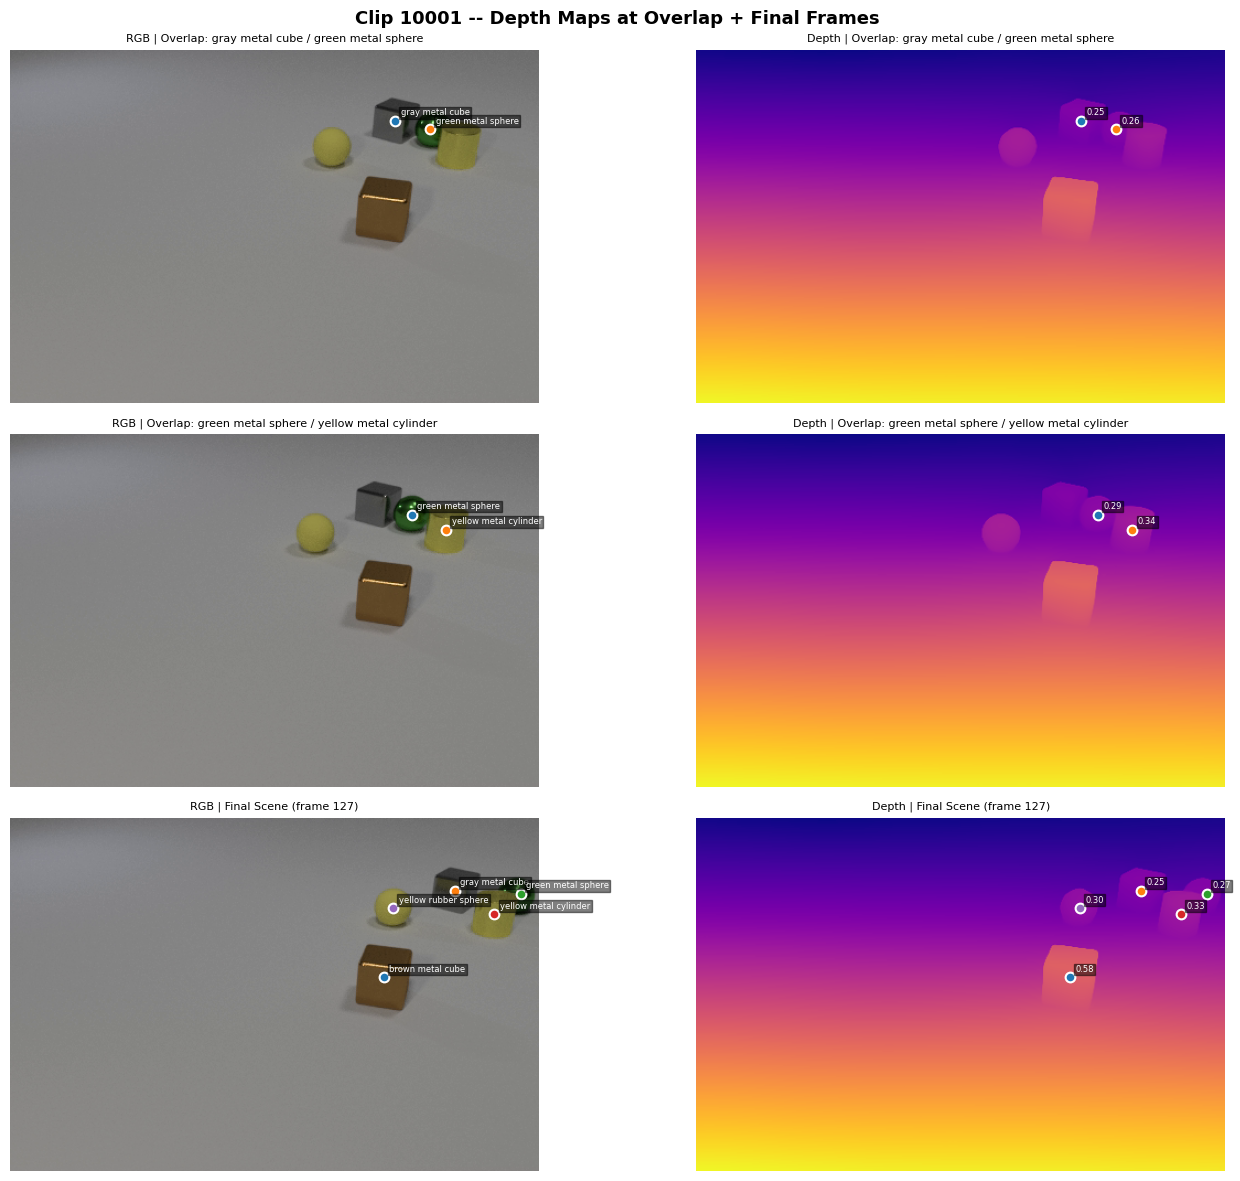

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02b_depth_clip10001.jpg

── Context String Preview: Clip 10001 ──────────────────────────
Depth information (relative estimates within each frame,
0 = closest to camera, 1 = farthest from camera).
Objects with depth difference below 0.08 are likely on the same collision plane.

Depth at spatial overlap events:
  - gray metal cube and green metal sphere at frame 99: depths 0.25 and 0.26, difference 0.01 (same collision plane).
  - green metal sphere and yellow metal cylinder at frame 92: depths 0.29 and 0.34, difference 0.05 (same collision plane).

Final scene depth (frame 127):
  - brown metal cube: depth 0.58
  - gray metal cube: depth 0.25
  - green metal sphere: depth 0.27
  - yellow metal cylinder: depth 0.33
  - yellow rubber sphere: depth 0.30



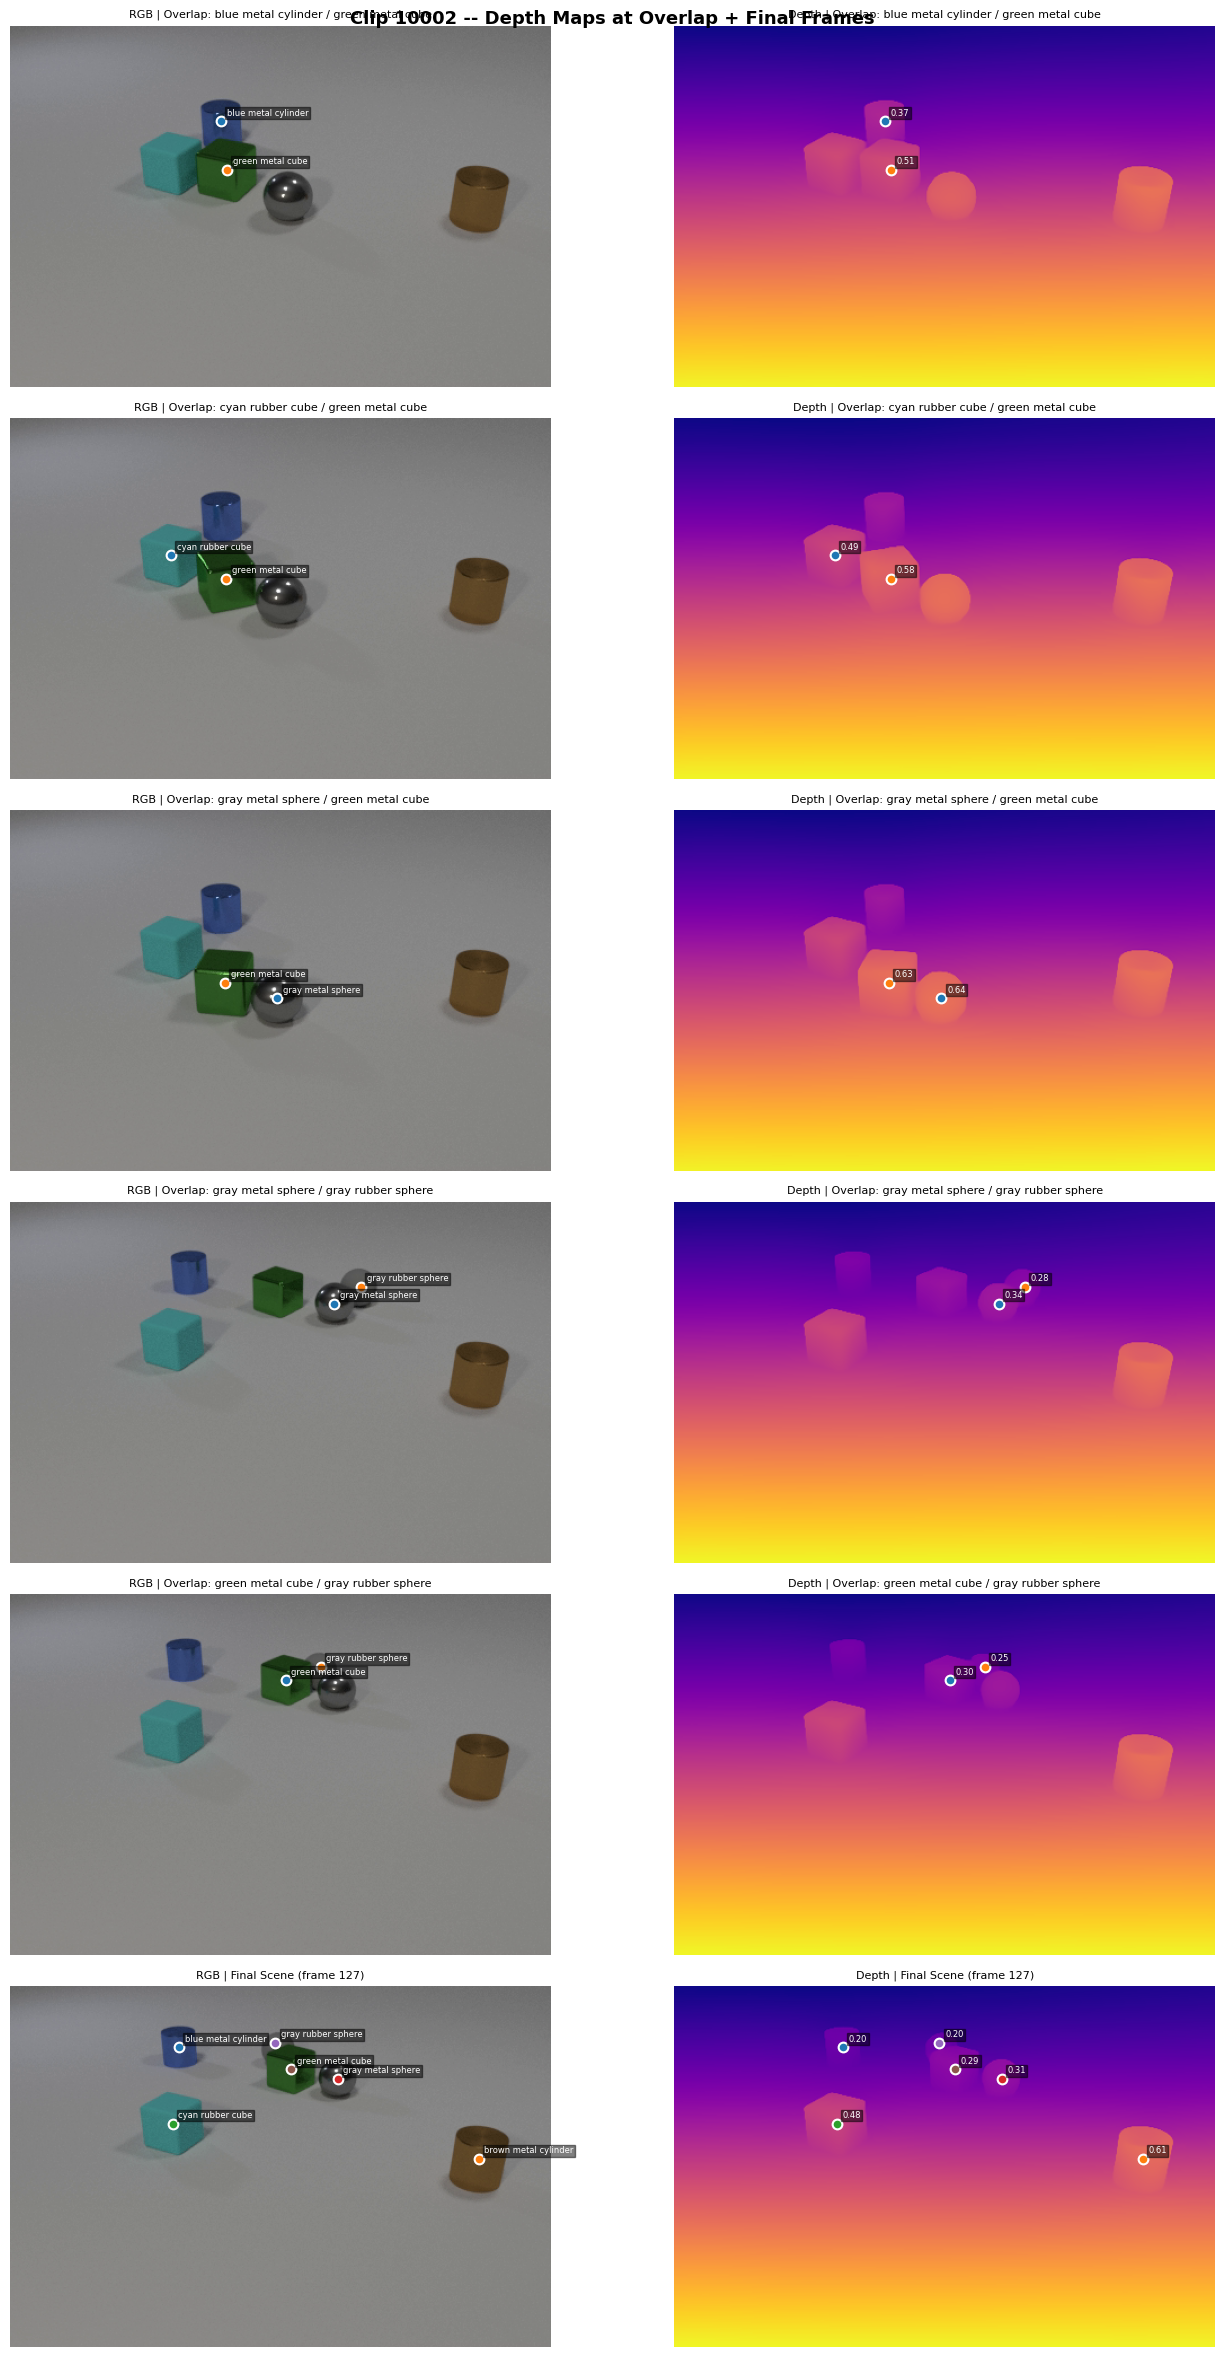

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02b_depth_clip10002.jpg

── Context String Preview: Clip 10002 ──────────────────────────
Depth information (relative estimates within each frame,
0 = closest to camera, 1 = farthest from camera).
Objects with depth difference below 0.08 are likely on the same collision plane.

Depth at spatial overlap events:
  - blue metal cylinder and green metal cube at frame 59: depths 0.37 and 0.51, difference 0.14 (different planes).
  - cyan rubber cube and green metal cube at frame 54: depths 0.49 and 0.58, difference 0.09 (different planes).
  - gray metal sphere and green metal cube at frame 51: depths 0.64 and 0.63, difference 0.01 (same collision plane).
  - gray metal sphere and gray rubber sphere at frame 106: depths 0.34 and 0.28, difference 0.06 (same collision plane).
  - green metal cube and gray rubber sphere at frame 115: depths 0.30 and 0.25, difference 0.05 (same collision plane).

Fina

In [27]:
# ── Cell 7 — Visuals + Context String Preview ──────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# DEPTH_THRESHOLD = 0.05  # empirically derived in Cell 5c
with open(os.path.join(BASE, "outputs/depth_threshold.json"), 'r') as f:
    DEPTH_THRESHOLD = json.load(f)['depth_collision_threshold']

def build_depth_context_string(vid_id, depth_data, threshold):
    """
    Build the depth contribution to the full context string for a clip.
    """
    lines = []
    lines.append("Depth information (relative estimates within each frame,")
    lines.append("0 = closest to camera, 1 = farthest from camera).")
    lines.append(f"Objects with depth difference below {threshold} are likely on the same collision plane.")
    lines.append("")

    # ── Overlap depths ───────────────────────────────────────────────────────
    lines.append("Depth at spatial overlap events:")
    n = int(depth_data['n_overlaps'])
    for i in range(n):
        obj_a   = str(depth_data[f'overlap_{i}_obj_a'])
        obj_b   = str(depth_data[f'overlap_{i}_obj_b'])
        frame   = int(depth_data[f'overlap_{i}_frame'])
        depth_a = float(depth_data[f'overlap_{i}_depth_a'])
        depth_b = float(depth_data[f'overlap_{i}_depth_b'])
        diff    = float(depth_data[f'overlap_{i}_diff'])
        plane   = "same collision plane" if diff < threshold else "different planes"
        lines.append(
            f"  - {obj_a.replace('_', ' ')} and {obj_b.replace('_', ' ')} "
            f"at frame {frame}: depths {depth_a:.2f} and {depth_b:.2f}, "
            f"difference {diff:.2f} ({plane})."
        )

    lines.append("")

    # ── Last frame depths ────────────────────────────────────────────────────
    lines.append("Final scene depth (frame 127):")
    last_keys = [k for k in depth_data.files if k.startswith('last__')]
    for key in sorted(last_keys):
        label = key.replace('last__', '').replace('_', ' ')
        depth = float(depth_data[key])
        lines.append(f"  - {label}: depth {depth:.2f}")

    return "\n".join(lines)

# ── Generate visuals + context string for each clip ─────────────────────────
for vid_id in SELECTED_IDS[:2]:
    out_path   = os.path.join(OUT_DEPTH, f"stage2_depth_{vid_id:05d}.npz")
    depth_data = np.load(out_path, allow_pickle=True)
    n_overlaps = int(depth_data['n_overlaps'])

    # ── Collect all frames to visualize: overlap frames + last frame ─────────
    frames_to_viz = []
    for i in range(n_overlaps):
        frames_to_viz.append({
            'frame'  : int(depth_data[f'overlap_{i}_frame']),
            'label'  : f"Overlap: {str(depth_data[f'overlap_{i}_obj_a']).replace('_',' ')} / "
                       f"{str(depth_data[f'overlap_{i}_obj_b']).replace('_',' ')}",
            'points' : [
                get_centroid_at_frame(vid_id, str(depth_data[f'overlap_{i}_obj_a']),
                                      int(depth_data[f'overlap_{i}_frame'])),
                get_centroid_at_frame(vid_id, str(depth_data[f'overlap_{i}_obj_b']),
                                      int(depth_data[f'overlap_{i}_frame']))
            ],
            'depths' : [float(depth_data[f'overlap_{i}_depth_a']),
                        float(depth_data[f'overlap_{i}_depth_b'])],
            'obj_labels': [
                str(depth_data[f'overlap_{i}_obj_a']).replace('_', ' '),
                str(depth_data[f'overlap_{i}_obj_b']).replace('_', ' ')
            ]
        })

    # Last frame
    last_keys  = [k for k in depth_data.files if k.startswith('last__')]
    last_points = []
    last_depths = []
    last_labels = []
    for key in sorted(last_keys):
        label  = key.replace('last__', '')
        cent   = get_centroid_at_frame(vid_id, label, 127)
        if cent:
            last_points.append(cent)
            last_depths.append(float(depth_data[key]))
            last_labels.append(label.replace('_', ' '))

    frames_to_viz.append({
        'frame'  : 127,
        'label'  : 'Final Scene (frame 127)',
        'points' : last_points,
        'depths' : last_depths,
        'obj_labels': last_labels
    })

    # ── Plot: 2 columns (RGB + depth map) per frame ─────────────────────────
    n_rows = len(frames_to_viz)
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
    fig.suptitle(f'Clip {vid_id} -- Depth Maps at Overlap + Final Frames',
                 fontsize=13, fontweight='bold')

    for row, fv in enumerate(frames_to_viz):
        pil_img, depth_norm = get_depth_map_normalized(vid_id, fv['frame'])
        ax_rgb = axes[row][0]
        ax_dep = axes[row][1]

        # RGB panel
        ax_rgb.imshow(pil_img)
        ax_rgb.set_title(f"RGB | {fv['label']}", fontsize=8)
        ax_rgb.axis('off')

        # Depth panel
        ax_dep.imshow(depth_norm, cmap='plasma', vmin=0, vmax=1)
        ax_dep.set_title(f"Depth | {fv['label']}", fontsize=8)
        ax_dep.axis('off')

        # Annotate centroids on both panels
        obj_labels_row = fv.get('obj_labels', None)
        for j, (pt, dv) in enumerate(zip(fv['points'], fv['depths'])):
            if pt is None:
                continue
            cx, cy = pt
            lbl    = obj_labels_row[j] if obj_labels_row else f"obj {j+1}"
            for ax, txt in [(ax_rgb, lbl), (ax_dep, f"{dv:.2f}")]:
                ax.plot(cx, cy, 'o', markersize=7,
                        markeredgecolor='white', markeredgewidth=1.5)
                ax.text(cx + 5, cy - 5, txt, fontsize=6, color='white',
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))

    plt.tight_layout()
    fig_path = os.path.join(FIGURES_DIR, f"02b_depth_clip{vid_id}.jpg")
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved -> {fig_path}")

    # ── Print context string preview ─────────────────────────────────────────
    print(f"\n── Context String Preview: Clip {vid_id} ──────────────────────────")
    ctx = build_depth_context_string(vid_id, depth_data, DEPTH_THRESHOLD)
    print(ctx)
    print()

print("Cell 7 complete.")

---
# Cell 8 — Drive Space Check + Completion Summary

In [28]:
# ── Cell 8 — Drive Space Check + Completion Summary ────────────────────────

npz_files   = [f for f in os.listdir(OUT_DEPTH)
                if f.startswith('stage2_depth_') and f.endswith('.npz')]
total_bytes = sum(
    os.path.getsize(os.path.join(OUT_DEPTH, f))
    for f in npz_files
)

print("── Stage 2 Depth Output Summary ───────────────────────────────")
print(f"  Clips processed : {len(npz_files)}")
print(f"  Files saved to  : {OUT_DEPTH}")
print(f"  Total size      : {total_bytes / 1e6:.3f} MB")
print(f"  Avg per clip    : {total_bytes / max(len(npz_files), 1) / 1e6:.3f} MB")
print()
print("── Files on Drive ─────────────────────────────────────────────")
for f in sorted(npz_files):
    fpath = os.path.join(OUT_DEPTH, f)
    print(f"  {f}  ({os.path.getsize(fpath) / 1e3:.1f} KB)")
print()
print("Notebook 02b complete. Proceed to 02c_raft.ipynb.")

── Stage 2 Depth Output Summary ───────────────────────────────
  Clips processed : 70
  Files saved to  : /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage2_depth
  Total size      : 0.361 MB
  Avg per clip    : 0.005 MB

── Files on Drive ─────────────────────────────────────────────
  stage2_depth_10001.npz  (4.0 KB)
  stage2_depth_10002.npz  (8.1 KB)
  stage2_depth_10003.npz  (2.4 KB)
  stage2_depth_10004.npz  (3.5 KB)
  stage2_depth_10005.npz  (4.0 KB)
  stage2_depth_10006.npz  (2.2 KB)
  stage2_depth_10007.npz  (4.0 KB)
  stage2_depth_10008.npz  (4.2 KB)
  stage2_depth_10009.npz  (2.4 KB)
  stage2_depth_10010.npz  (3.5 KB)
  stage2_depth_10011.npz  (9.4 KB)
  stage2_depth_10012.npz  (2.7 KB)
  stage2_depth_10013.npz  (5.1 KB)
  stage2_depth_10014.npz  (7.7 KB)
  stage2_depth_10015.npz  (6.8 KB)
  stage2_depth_10016.npz  (5.3 KB)
  stage2_depth_10017.npz  (6.6 KB)
  stage2_depth_10018.npz  (6.4 KB)
  stage2_depth_10019.npz  (5.3 KB)
  stag

---